In [1]:
from platform import python_version
print(python_version())

3.11.14


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as npmtd
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.GDC_lib import GDC
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'TCGA-BRCA'
PSI_ID = 'TCGA-ACC'
PSI_ID = 'TCGA-CESC'
PSI_ID = 'TCGA-PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/config/all_lfc_cutoffs_TCGA-PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=False, verbose=False)
# print("\nEcho Parameters:")
# print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD
>>> Tumor


### Get all programs

In [6]:
gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

#--------- chose a disease --------------------
DISEASE_ID = 'ACC'
DISEASE_ID = 'PAAD'

In [7]:
verbose=False
force=False

method='deseq2'
imax_tumor=250
imax_normal=50

gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

df_psi = gdc.open_primary_sites_cbio(verbose=False)


df_psi = df_psi[ (df_psi.disease_id == DISEASE_ID) & (~pd.isnull(df_psi.primary_site)) & (~pd.isnull(df_psi.cbioportal_study_id)) ].copy()
dfa = df_psi.groupby(['prog_id', 'psi_id', 'disease_id', 'primary_site', 'cbioportal_study_id']).size().reset_index()

dic = {}

for ipsi, row in dfa.iterrows():
    prog_id = row.prog_id

    if prog_id == 'CCLE':
        continue

    psi_id = row.psi_id
    disease_id = row.disease_id
    primary_site = row.primary_site

    print(f"{int(ipsi)+1}) prog_id {prog_id}, psi_id {psi_id}, primary_site {primary_site}, disease_id {disease_id}", end=" ")

    _ = gdc.get_primary_sites(prog_id=prog_id, verbose=verbose)

    ret = gdc.set_primary_site(psi_id = psi_id)

    if not ret:
        print(f"Error: failed to set primary site for {prog_id} {psi_id}")
        continue

    df_lfc = pd.DataFrame()

    case = case_list[0]
    
    print(f"case = {case}")

    # print(gdc.root_project, gdc.root_disease, '\n')

    df_tumor, df_normal, df_gtex_ctrl = gdc.calc_file_expression_tumor_normal_gtex(imax_tumor=imax_tumor, imax_normal=imax_normal, force=force, verbose=verbose)
    print(f"df_tumor {df_tumor.shape}")

    df_degs, df_lfc, degs_txt, msg = gdc.calc_degs(
        prog_id = prog_id,
        psi_id = psi_id,
        root_src = gdc.root_src,
        run_conda = True,
        lfc_cutoff = 1.0,
        fdr_cutoff = 0.05,
        method = method,
        imax_tumor = imax_tumor,
        imax_normal = imax_normal,
        force = force,
        verbose = verbose,
    )

    if not df_tumor.empty:
        dic[ipsi] ={}

        dic[ipsi]['primary_site'] = [prog_id, psi_id, disease_id, primary_site]
        dic[ipsi]['df_tumor'] = df_tumor
        dic[ipsi]['degs'] = df_degs
        dic[ipsi]['lfc'] = df_lfc

        if not df_normal.empty:
            dic[ipsi]['df_normal'] = df_normal

        if not df_gtex_ctrl.empty:
            dic[ipsi]['df_gtex'] = df_gtex_ctrl

        print(f"Tumor samples: {df_tumor.shape[1]}, Normal samples: {df_normal.shape[1]}, GTEx controls: {df_gtex_ctrl.shape[1]}\n")

    print("")

print("\n--------------- end ---------------")


2) prog_id CPTAC, psi_id PAAD, primary_site Pancreas, disease_id PAAD case = Tumor
df_tumor (60616, 216)
Tumor samples: 216, Normal samples: 53, GTEx controls: 17


3) prog_id CPTAC, psi_id PAAD_GDC, primary_site Pancreas, disease_id PAAD case = Tumor
df_tumor (60616, 216)
Tumor samples: 216, Normal samples: 53, GTEx controls: 17


4) prog_id TCGA, psi_id TCGA-PAAD, primary_site Pancreas, disease_id PAAD case = Tumor
df_tumor (60616, 34)
Tumor samples: 34, Normal samples: 4, GTEx controls: 17



--------------- end ---------------


In [8]:
for i, dic2 in dic.items():
    print(f"{i}: {dic2['primary_site']}")

    df_tumor = dic2['df_tumor']
    degs = dic2['degs']
    df_lfc = dic2['lfc']
    print("df_tumor", df_tumor.shape)
    print("degs", len(degs))
    print("df_lfc", len(df_lfc))
    print("\n")

1: ['CPTAC', 'PAAD', 'PAAD', 'Pancreas']
df_tumor (60616, 216)
degs 13502
df_lfc 55228


2: ['CPTAC', 'PAAD_GDC', 'PAAD', 'Pancreas']
df_tumor (60616, 216)
degs 13672
df_lfc 55229


3: ['TCGA', 'TCGA-PAAD', 'PAAD', 'Pancreas']
df_tumor (60616, 34)
degs 9746
df_lfc 37112




In [9]:
df_tumor1 = dic[1]['df_tumor']
df_tumor2 = dic[2]['df_tumor']
df_tumor3 = dic[3]['df_tumor']


In [10]:
symbs1 = set(df_tumor1.symbol)
symbs2 = set(df_tumor2.symbol)
symbs3 = set(df_tumor3.symbol)

len(symbs1), len(symbs2), len(symbs3)


(59427, 59427, 59427)

In [11]:
common12 = symbs1 & symbs2
common13 = symbs1 & symbs3
common23 = symbs2 & symbs3

len(common12), len(common13), len(common23)

(59427, 59427, 59427)

In [12]:
diff12 = symbs1 - symbs2
diff13 = symbs1 - symbs3
diff23 = symbs2 - symbs3

len(diff12), len(diff13), len(diff23)

(0, 0, 0)

In [15]:
cols = ['symbol', 'biotype']
dfn = pd.merge(df_tumor1, df_tumor2.drop(columns=cols), on='geneid', how='inner')
dfn = pd.merge(dfn, df_tumor3.drop(columns=cols), on='geneid', how='inner')

stri = f"There are {dfn.shape[1]-3} samples merging studies"
print(stri)
dfn.shape

There are 457 samples merging studies


(60616, 460)

In [14]:
dfn.head(3)

,geneid,symbol,biotype,tumor_1_x,tumor_2_x,tumor_3_x,tumor_4_x,tumor_5_x,tumor_6_x,tumor_7_x,...,tumor_22,tumor_23,tumor_24,tumor_25,tumor_26,tumor_27,tumor_28,tumor_29,tumor_30,tumor_31
0,ENSG00000000003,TSPAN6,protein_coding,18,0,6,2,7,0,4,...,1060,1221,210,18,155,36,84,182,323,192
1,ENSG00000000005,TNMD,protein_coding,39,23,3,15,13,13,10,...,0,1,87,4,2,0,1,8,1,0
2,ENSG00000000419,DPM1,protein_coding,48,11,13,5,27,5,5,...,1056,843,474,711,493,744,528,457,447,524


In [17]:
perc_min_samples = 0.25 
top_n: int = 10_000

df_sel, df_cpm,  dfg_filt, df_scaled = gdc.cluster_data(dfn.drop(columns='biotype'), perc_min_samples, top_n)
df_cpm.shape, df_sel.shape

sample_cols 457 and min_samples


((20024, 457), (457, 10000))

In [18]:
df_sel.head(3)

geneid,ENSG00000270641,ENSG00000262619,ENSG00000281383,ENSG00000189223,ENSG00000256462,ENSG00000230535,ENSG00000229732,ENSG00000249119,ENSG00000286471,ENSG00000206072,...,ENSG00000267871,ENSG00000119280,ENSG00000286599,ENSG00000185532,ENSG00000249435,ENSG00000153132,ENSG00000246203,ENSG00000271964,ENSG00000047410,ENSG00000145246
tumor_1_x,14.479,10.816,3.418,13.593,0.000,7.171,0.000,9.160,7.828,1.145,...,2.975,3.012,7.552,2.081,1.387,3.445,4.117,4.291,4.150,1.687
tumor_2_x,13.720,10.877,0.000,13.295,0.496,8.709,5.514,0.496,8.294,3.265,...,4.087,3.202,8.000,0.000,3.202,2.350,5.956,1.952,2.838,0.000
tumor_3_x,14.420,12.968,10.809,13.560,1.684,9.790,0.000,8.637,9.940,1.684,...,2.440,3.300,7.099,2.440,2.111,2.708,4.387,3.128,4.896,3.719


In [19]:
print(df_scaled.shape)

(457, 10000)


In [20]:
df_pca = gdc.calc_PCA(df_scaled, n_components=10, verbose=False)
df_pca.shape

(457, 3)

In [25]:
df_eval, df_samp_clusters = gdc.calc_best_cluster(df_pca=df_pca, min_clusters = 6, max_clusters = 12)
df_eval

,k,silhouette
0,6,0.584
1,7,0.492
2,8,0.443
3,9,0.390
4,10,0.391
5,11,0.372
6,12,0.383


In [26]:
df_samp_clusters

,sample,cluster
0,tumor_1_x,3
1,tumor_2_x,4
2,tumor_3_x,3
3,tumor_4_x,4
4,tumor_5_x,3
...,...,...
452,tumor_27,2
453,tumor_28,2
454,tumor_29,2
455,tumor_30,2


In [ ]:
df_samp_clusters.groupby('cluster').size()

cluster
1    202
2     33
3     78
4    102
5     24
6     18
dtype: int64

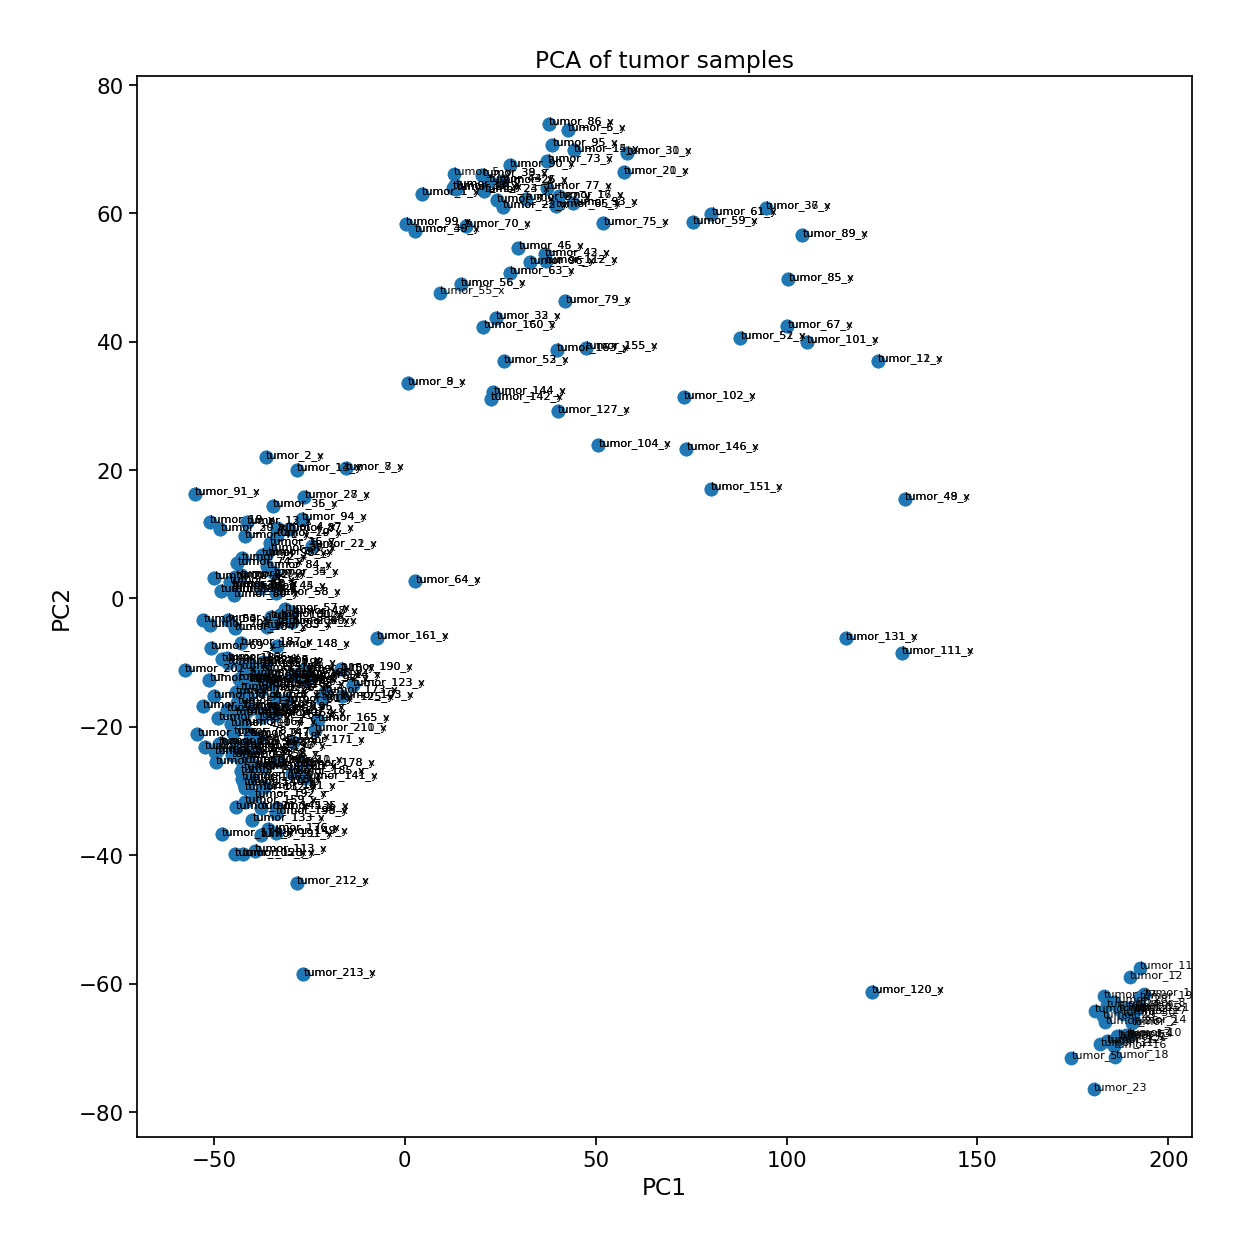

In [28]:
gdc.plot_PCA(df_pca, figsize=(12, 12))

### UMAP

In [29]:
n_neighbors=5
min_dist=0.2
metric="euclidean"

df_umap = gdc.calc_PCA_UMAP(df_pca=df_pca, df_samp_clusters=df_samp_clusters, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric)

df_umap

/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,UMAP1,UMAP2,sample,cluster
0,1.709,14.266,tumor_1_x,3
1,7.277,5.321,tumor_2_x,4
2,17.772,3.970,tumor_3_x,3
3,11.170,-1.499,tumor_4_x,4
4,8.227,19.470,tumor_5_x,3
...,...,...,...,...
452,3.937,5.630,tumor_27,2
453,3.935,5.625,tumor_28,2
454,4.106,5.780,tumor_29,2
455,2.105,4.256,tumor_30,2


In [30]:
df_umap.groupby('cluster').size()

cluster
1    202
2     33
3     78
4    102
5     24
6     18
dtype: int64

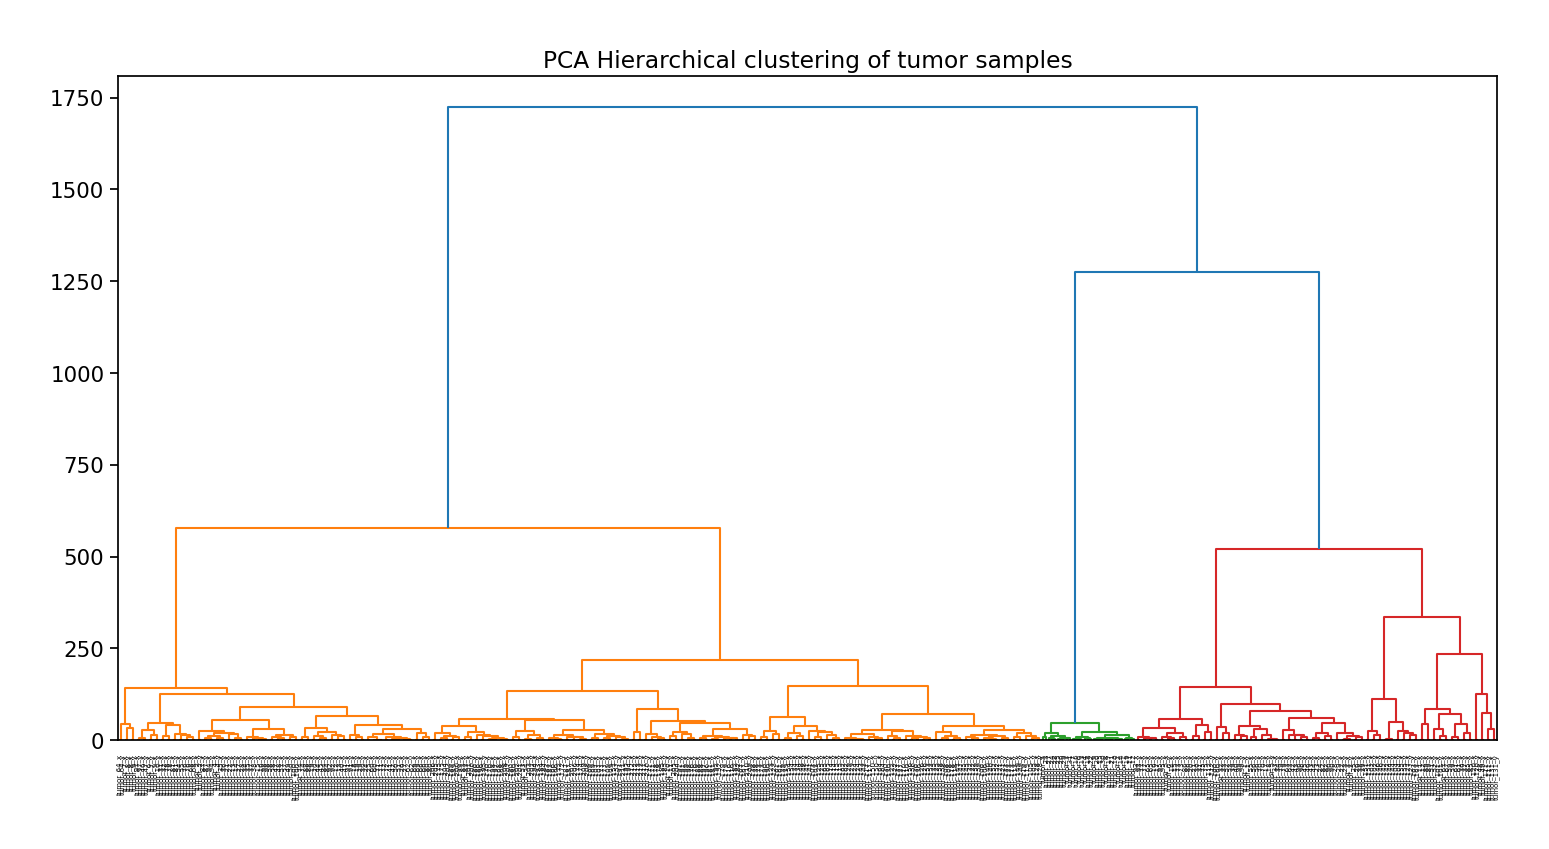

In [35]:
gdc.plot_HCA_PCA(df_pca, figsize=(15,8))

### Cut tree into k clusters:

In [90]:
method_hca = "ward"
criterion="maxclust"
verbose = False

n_clusters=10


df_hca = gdc.cut_HCA_PCA(df_pca=df_pca, method=method_hca, n_clusters=n_clusters, criterion=criterion, verbose=verbose)

df_hca

,sample,cluster
0,tumor_1_x,7
1,tumor_2_x,1
2,tumor_3_x,7
3,tumor_4_x,1
4,tumor_5_x,6
...,...,...
452,tumor_27,5
453,tumor_28,5
454,tumor_29,5
455,tumor_30,5


In [91]:
df_hca.groupby('cluster').size()

cluster
1     104
2     108
3      28
4      66
5      31
6      26
7      50
8      18
9      18
10      8
dtype: int64

In [101]:
dfclu_samp = df_hca.groupby('cluster').size().reset_index(name='samples')
dfclu_samp

,cluster,samples
0,1,104
1,2,108
2,3,28
3,4,66
4,5,31
5,6,26
6,7,50
7,8,18
8,9,18
9,10,8


In [92]:
dfc_log = np.log2(df_cpm + 1)

gene_annot = (
    dfg_filt[["geneid", "symbol"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

dfall, dfsig = gdc.find_cluster_signature_genes(df_logcpm=dfc_log, df_samp_clusters=df_hca, gene_annot=gene_annot)

In [93]:
dfall.head(3)

,geneid,cluster,n_in,n_out,mean_in,mean_out,lfc,pvalue,fdr,symbol
0,ENSG00000230535,1,104,353,9.564,3.275,6.289,9.965e-69,1.050e-65,BASP1P1
1,ENSG00000262619,1,104,353,11.497,5.285,6.212,6.212e-62,3.658e-59,LINC00621
2,ENSG00000189223,1,104,353,12.107,6.447,5.660,9.354e-80,1.561e-76,PAX8-AS1


In [94]:
cluster_list = np.unique(dfall.cluster)
cluster_list

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int32)

In [95]:
LFC_cutoff=2
FDR_cutoff=1e-3

ncluster = 1

df2 = dfsig[dfsig.cluster == ncluster]
df2 = df2[ (df2['lfc'].abs() >= LFC_cutoff) & (df2['fdr'] < FDR_cutoff) ]
print(len(df2))
df2.head(3)

225


,geneid,cluster,n_in,n_out,mean_in,mean_out,lfc,pvalue,fdr,symbol
0,ENSG00000230535,1,104,353,9.564,3.275,6.289,9.965e-69,1.050e-65,BASP1P1
1,ENSG00000262619,1,104,353,11.497,5.285,6.212,6.212e-62,3.658e-59,LINC00621
2,ENSG00000189223,1,104,353,12.107,6.447,5.660,9.354e-80,1.561e-76,PAX8-AS1


In [96]:
dic = {}

for ncluster in cluster_list:
    df2 = dfsig[dfsig.cluster == ncluster]
    df2 = df2[ (df2['lfc'].abs() > LFC_cutoff) & (df2['fdr'] < FDR_cutoff) ]

    symbols = np.unique(df2.symbol)

    dic[ncluster] = set(symbols)

    print(f"Cluster {ncluster}: {len(symbols)} signature genes")

    fname = f"cluster_{ncluster}-{n_clusters}_signature_genes.txt"
    filename = gdc.root_lfc / fname

    write_txt('\n'.join(symbols), filename)


Cluster 1: 225 signature genes
Cluster 2: 129 signature genes
Cluster 3: 141 signature genes
Cluster 4: 278 signature genes
Cluster 5: 5068 signature genes
Cluster 6: 1489 signature genes
Cluster 7: 805 signature genes
Cluster 8: 1754 signature genes
Cluster 9: 3992 signature genes
Cluster 10: 1655 signature genes


In [97]:
df_cluster = gdc.write_clusters(dfall, dfsig, LFC_cutoff=LFC_cutoff, FDR_cutoff=FDR_cutoff, verbose=False)

df_cluster

,ncluster,ngenes,genes
0,1,225,"[BASP1P1, LINC00621, PAX8-AS1, TSIX, PGR-AS1, AP003306.2, AL356311.1, AL0785..."
1,2,129,"[AC009570.2, NR1H2, NKX2-1-AS1, AC020656.1, AC007552.2, AL645939.1, AF001548..."
2,3,141,"[AL732437.1, AC083841.2, AC019349.1, AC078816.1, AC114812.2, CALML3-AS1, LIN..."
3,4,278,"[AL732437.1, CALML3-AS1, AC019349.1, DSG1-AS1, AC083841.2, SERPINB11, AC0788..."
4,5,5068,"[SERPINA1, BGN, TIMP1, S100A6, SPARC, B2M, IGFBP4, COL1A2, RPSA, LYZ, RPS12,..."
5,6,1497,"[FP671120.7, MTND6P4, RNU4-2, RNU4-1, MT-ND6, SCN5A, AC027250.2, RN7SKP80, M..."
6,7,820,"[FP671120.7, MTND6P4, MT-ND6, PAX8-AS1, RNU4-2, AC008670.1, AC010336.3, TSIX..."
7,8,1756,"[FP671120.7, KRT6A, KRT5, KRT17, MTND6P4, PKP1, S100A9, KRT16, DSG1-AS1, SER..."
8,9,3992,"[RNU4-2, RNU4-1, MT-ATP8, MT-TM, FP671120.7, MTND6P4, MTRNR2L12, RNU5A-1, MU..."
9,10,1655,"[MT-ATP8, MUC2, MT-ND1, MTATP8P1, MTRNR2L12, MT-ND2, MUC3A, PRRG3, MTND2P28,..."


In [105]:
dic2 = {}

for sel_clu in range(1, len(dic)+1):
    set0 = dic[sel_clu]

    for key, setx in dic.items():
        if key != sel_clu:
            set0 = set0 - dic[key]

    uniq_list = list(set0)
    s_lista = "; ".join(uniq_list)
    dic2[sel_clu] = {}
    
    dic2[sel_clu]['cluster'] = sel_clu
    dic2[sel_clu]['n_unique_genes'] = len(uniq_list)
    dic2[sel_clu]['unique_genes'] = s_lista


df_uniq = pd.DataFrame.from_dict(dic2, orient='index')

df_uniq = df_uniq.merge(dfclu_samp, on='cluster', how='left')

cols = ['cluster', 'samples', 'n_unique_genes', 'unique_genes', ]
df_uniq = df_uniq[cols]
ren_cols = ['cluster', 'n_samples', 'n_unique_genes', 'unique_genes', ]
df_uniq.columns = ren_cols

df_uniq

,cluster,n_samples,n_unique_genes,unique_genes
0,1,104,117,GLYCTK; AC105219.1; GDF5-AS1; ERI2; SHISA6; AC010327.4; AC097374.1; AC099482...
1,2,108,108,TARID; BRWD1P3; AC068580.3; HLA-DQB1-AS1; C12orf60; EGILA; AL033519.5; ADGRD...
2,3,28,13,AC006487.1; AC011287.1; AL050404.1; AL139241.1; AC109361.2; BAALC-AS1; AL365...
3,4,66,93,AC010680.4; ITGA6-AS1; AC006262.2; DELEC1; AC009119.1; AC008742.1; AC126696....
4,5,31,1704,HLA-H; PCMT1; CLK2; METTL14; RTL8C; INPP5A; GALNT7; TOR1AIP1; HSPD1; NUDT12;...
5,6,26,79,WEE2; AC134050.1; AC004696.2; MDM2; TRIM61; LINC00411; AL353748.1; AC025171....
6,7,50,193,AL358232.1; AC073592.1; NCLP1; LETM2; SMIM18; RNF113B; AL009178.3; AC009166....
7,8,18,230,AC010486.3; SFXN4P1; A2ML1; RPL5P17; CRYBG2; NPM1P30; AC124944.3; AC009063.3...
8,9,18,450,MIR194-2HG; TMEM144; DNMT1; FYB2; CPEB3; CBL; GRIN2A; SLFN13; NAALADL2; ERIC...
9,10,8,160,HSCB; LINC-PINT; RWDD2B; CTBP1-DT; SLC38A6; C2CD2L; GORAB-AS1; SIX5; UBAP2; ...


In [107]:
df_uniq.n_samples.sum()

457

In [106]:
fname = f"clusters_{n_clusters}.tsv"
pdwritecsv(df_cluster, fname, gdc.root_lfc)

fname = f"clusters_{n_clusters}_unique_symbols.tsv"
pdwritecsv(df_uniq, fname, gdc.root_lfc)


True

In [100]:
gdc.root_lfc

PosixPath('/home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/lfc')

### UMAP

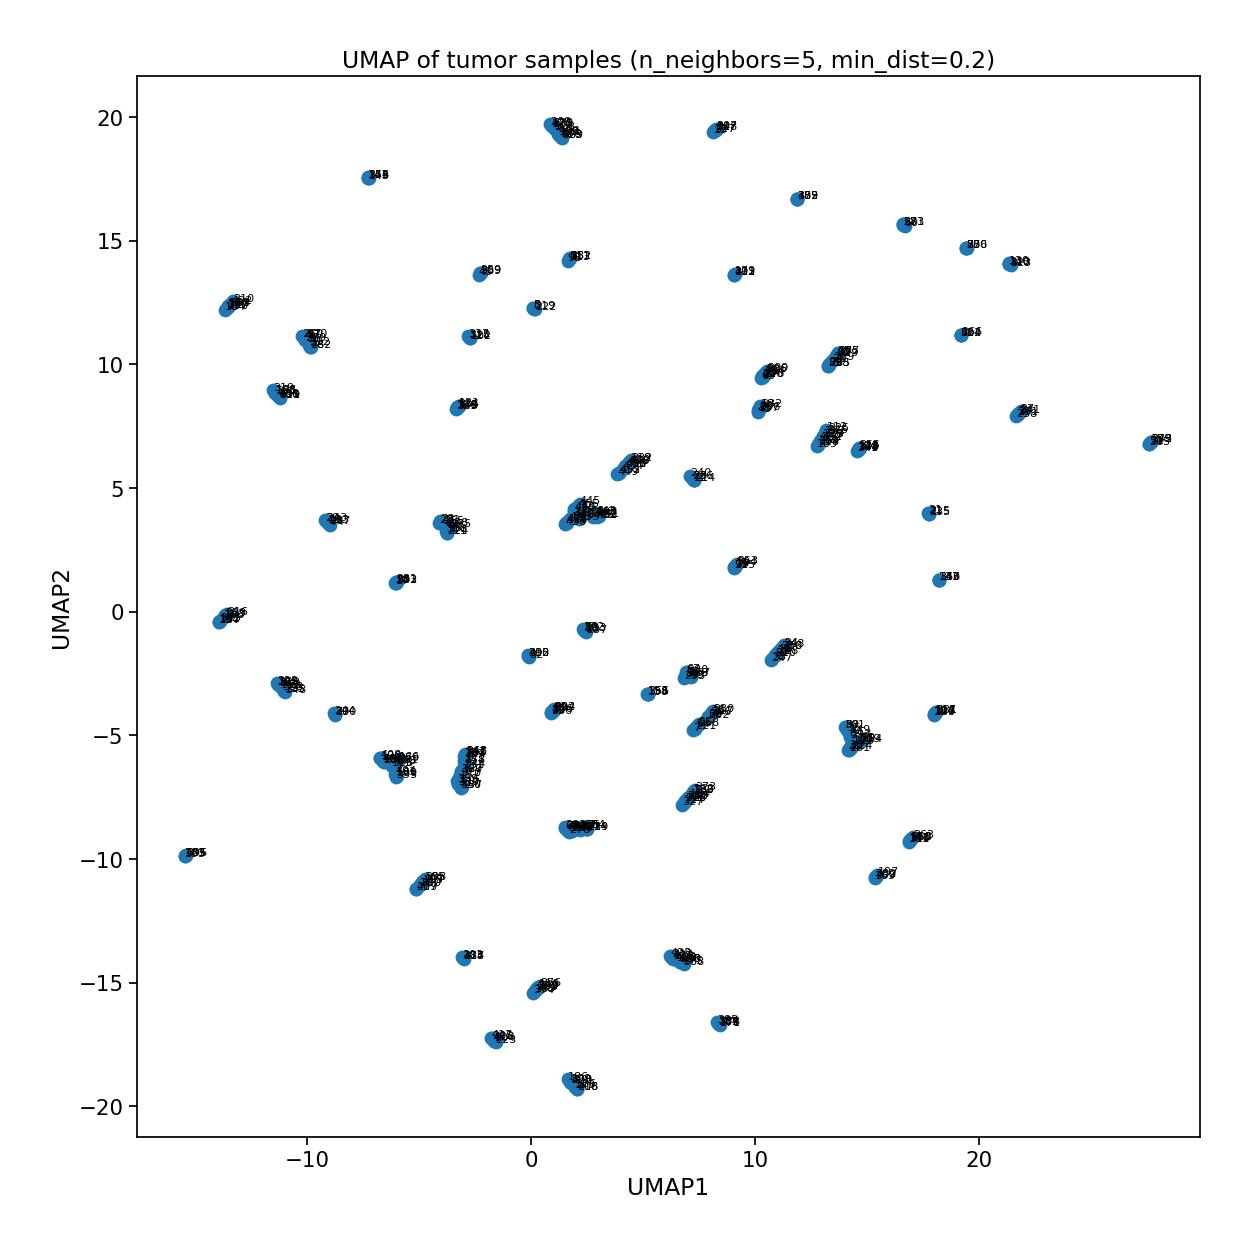

In [31]:
gdc.plot_PCA_UMAP(df_umap=df_umap, n_neighbors=n_neighbors, min_dist=min_dist, figsize=(12, 12))

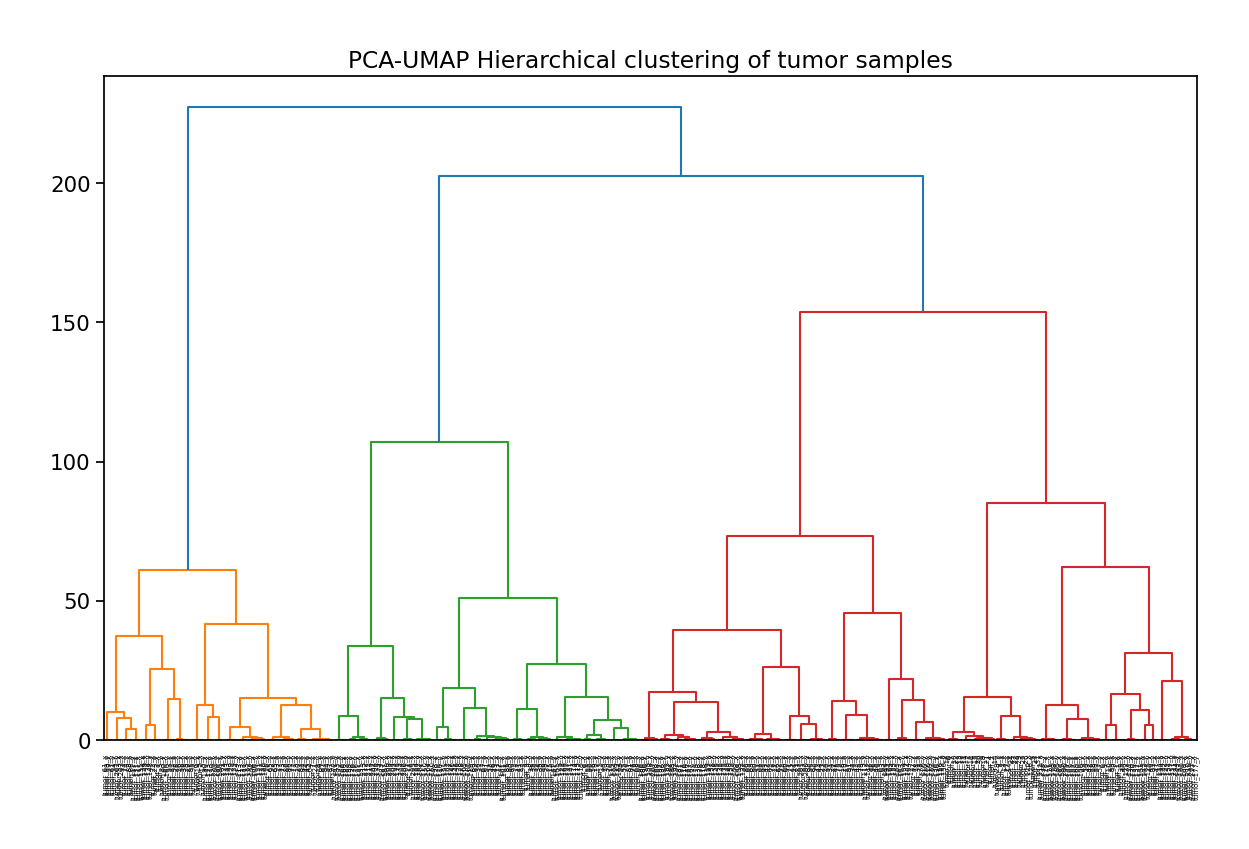

In [45]:
gdc.plot_HCA_PCA_UMAP(df_umap, figsize=(12, 8))

In [ ]:
find_cluster_signature_genes

### HCA